# BRCA Tumor-Infiltrating Lymphocyte (TIL) Analysis
## TCGA Breast Cancer Cohort

This notebook performs an end-to-end quantitative analysis of Tumor-Infiltrating Lymphocytes (TILs) in breast cancer (BRCA) whole-slide images from The Cancer Genome Atlas (TCGA). Cell-level predictions from a deep learning pathology model are used to compute per-slide TIL ratios, which are then correlated with patient survival outcomes.

**Objective:** Determine whether high TIL infiltration in breast tumors is associated with improved overall survival.

**Data Sources:**
- **Whole-slide image model outputs**: Per-cell classification CSVs containing region probabilities (`region_prob_*`) and cell-type probabilities (`prob_*`) for ~1,100 TCGA-BRCA slides
- **GDC manifest**: TCGA slide filenames and metadata
- **TCGA Clinical Data**: PAN-Cancer patient follow-up data (`clinical_PANCAN_patient_with_followup.tsv`)

**Pipeline Overview:**
1. Load GDC manifest and locate model-output CSVs
2. Resolve slide filenames to on-disk paths
3. Compute per-slide TIL ratio (inflammatory cells in tumor region / all cells in tumor region)
4. Run computation in parallel across all slides
5. Merge with TCGA clinical survival data
6. Kaplan-Meier survival analysis stratified by TIL ratio

## Step 1: Data Loading & Setup

Load the GDC manifest to obtain the list of TCGA-BRCA slide filenames, and scan the model-output CSV directory to identify which slides have available predictions. Only slides present in both sources are retained for downstream analysis.

In [15]:
import os
import pandas as pd

manifest_path = "gdc_manifest.2026-04-11.103314.txt"
csv_dir = "results/03262026/objects/model-outputs-csv"

# Load manifest stems (lowercase)
manifest_df = pd.read_csv(manifest_path, sep="\t")
manifest_df["stem"] = manifest_df["filename"].str.replace(r"\.svs$", "", regex=True).str.lower()

# Get CSV stems (lowercase)
csv_stems = {os.path.splitext(f)[0].lower() for f in os.listdir(csv_dir) if f.endswith(".csv")}

# Keep only cases present in both
common_mask = manifest_df["stem"].isin(csv_stems)
df_common = manifest_df[common_mask].reset_index(drop=True)

print(f"Cases in both manifest and model-outputs-csv: {len(df_common)}")
df_common


Cases in both manifest and model-outputs-csv: 1100


,id,filename,md5,size,state,stem
0,4730b23e-aea1-49a2-ba63-2231fd88b592,TCGA-E2-A14P-01Z-00-DX1.663B02FF-C64B-41A6-868...,22b18a6eea2790519592033b43f6f423,1597343893,released,tcga-e2-a14p-01z-00-dx1.663b02ff-c64b-41a6-868...
1,554855d7-4e21-406b-8f9f-458b1e7c89c9,TCGA-A7-A0CD-01Z-00-DX1.F045B9C8-049C-41BF-843...,d148f6d71ac283e653c29ee7e77b2f23,280966835,released,tcga-a7-a0cd-01z-00-dx1.f045b9c8-049c-41bf-843...
2,4eec69ca-381b-4c17-b3e9-49492d71560e,TCGA-5L-AAT1-01Z-00-DX1.F3449A5B-2AC4-4ED7-BF4...,12416cc41421ba836c7e11aad25594f4,592769341,released,tcga-5l-aat1-01z-00-dx1.f3449a5b-2ac4-4ed7-bf4...
3,2b5c424a-e8d9-4412-b612-e3adcf98dffd,TCGA-AC-A62V-01Z-00-DX1.2D8994FD-58B8-43C1-B99...,f65cbedaaa080e60a7da6a4c7b29d20f,57528662,released,tcga-ac-a62v-01z-00-dx1.2d8994fd-58b8-43c1-b99...
4,52f4cb6c-d5b2-4e12-b664-22e85c4ad780,TCGA-A2-A0YM-01Z-00-DX1.A48B4C96-2CC5-464C-98B...,ca61de0f9c1b3c6d5eaab29efd698abf,863053399,released,tcga-a2-a0ym-01z-00-dx1.a48b4c96-2cc5-464c-98b...
...,...,...,...,...,...,...
1095,693d0470-eecc-4457-a97a-d35ea2268188,TCGA-A7-A13G-01Z-00-DX1.C258C545-8C1F-41D4-846...,d5df4e4e00112f7c92abef5b82560e1b,125960225,released,tcga-a7-a13g-01z-00-dx1.c258c545-8c1f-41d4-846...
1096,d5a53214-78c1-4d1b-b890-207faad31982,TCGA-LL-A441-01Z-00-DX1.33B13078-BB14-4C42-88A...,80f2f50d45439bd4391440aca133516b,1359643667,released,tcga-ll-a441-01z-00-dx1.33b13078-bb14-4c42-88a...
1097,994db278-3ed5-4527-9066-a45867be7ef2,TCGA-GM-A2D9-01Z-00-DX1.AF4BF2DD-05FB-400B-A1B...,03a2a7e636af32a4bd972db4b667a73a,1364080617,released,tcga-gm-a2d9-01z-00-dx1.af4bf2dd-05fb-400b-a1b...
1098,bc676ee2-d0e4-48ef-9d1d-5a90e79b4fb2,TCGA-D8-A1XS-01Z-00-DX1.E5C78E5A-947C-499D-9E9...,860e37b61b886c4a52b5d2ff3f2cc4fb,1427409965,released,tcga-d8-a1xs-01z-00-dx1.e5c78e5a-947c-499d-9e9...


## Step 2: File Resolution

Build a case-insensitive mapping from slide stem names to their actual filenames on disk. This ensures robust file lookup regardless of naming inconsistencies between the manifest and the file system. All cases are verified to have a corresponding CSV on disk.

In [16]:
# Build case-insensitive mapping: lowercase stem -> actual filename on disk
csv_files_on_disk = os.listdir(csv_dir)
stem_to_filename = {
    os.path.splitext(f)[0].lower(): f
    for f in csv_files_on_disk
    if f.endswith(".csv")
}

# Verify all 1100 cases resolve to a file
missing = [row["stem"] for _, row in df_common.iterrows() if row["stem"] not in stem_to_filename]
print(f"Cases with no matching CSV on disk: {len(missing)}")


Cases with no matching CSV on disk: 0


## Step 3: TIL Ratio Computation Function

Define the `compute_til_ratio` function, which processes a single slide's cell-detection CSV to compute:
- **Cells in tumor region**: cells whose highest `region_prob_*` score corresponds to `region_prob_Tumor`
- **Inflammatory cells in tumor region**: subset of above whose highest `prob_*` score is `prob_inflammatory`
- **TIL ratio**: `n_inflammatory_in_tumor / n_total_in_tumor`

Slides with no tumor-region cells receive a `NaN` ratio.

In [17]:
def compute_til_ratio(csv_path):
    """
    For a single slide CSV, compute:
      - n_total_in_tumor:        cells whose argmax(region_prob_*) == region_prob_Tumor
      - n_inflammatory_in_tumor: subset of above whose argmax(prob_*) == prob_inflammatory
      - til_ratio:               n_inflammatory_in_tumor / n_total_in_tumor (NaN if denom == 0)
    Returns NaN counts and NaN ratio on parse failure.
    """
    try:
        df = pd.read_csv(csv_path, engine="c")
    except Exception:
        try:
            df = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")
        except Exception:
            return 0, 0, float("nan")

    prob_cols = [c for c in df.columns if c.startswith("prob_")]
    region_prob_cols = [c for c in df.columns if c.startswith("region_prob_")]

    if not prob_cols or not region_prob_cols:
        return 0, 0, float("nan")

    # Only call idxmax on rows with at least one non-NaN value, then reindex
    # to fill missing rows with False — avoids both the all-NA and dtype warnings.
    valid_region = df[region_prob_cols].notna().any(axis=1)
    valid_cell = df[prob_cols].notna().any(axis=1)

    in_tumor = (
        df.loc[valid_region, region_prob_cols].idxmax(axis=1)
        .eq("region_prob_Tumor")
        .reindex(df.index, fill_value=False)
    )

    is_inflammatory = (
        df.loc[valid_cell, prob_cols].idxmax(axis=1)
        .eq("prob_inflammatory")
        .reindex(df.index, fill_value=False)
    )

    n_total_in_tumor = int(in_tumor.sum())
    n_inflammatory_in_tumor = int((in_tumor & is_inflammatory).sum())
    til_ratio = n_inflammatory_in_tumor / n_total_in_tumor if n_total_in_tumor > 0 else float("nan")

    return n_inflammatory_in_tumor, n_total_in_tumor, til_ratio


## Step 4: Parallel TIL Ratio Computation

Apply `compute_til_ratio` across all ~1,100 slides using a `ThreadPoolExecutor` with 16 workers. Progress is tracked with a `tqdm` progress bar. Results are collected into `df_til`, one row per slide.

In [18]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

def _process_row(stem, filename):
    actual_filename = stem_to_filename[stem]
    csv_path = os.path.join(csv_dir, actual_filename)
    n_infl, n_tumor, ratio = compute_til_ratio(csv_path)
    return {
        "filename": filename,
        "stem": stem,
        "n_inflammatory_in_tumor": n_infl,
        "n_total_in_tumor": n_tumor,
        "til_ratio": ratio,
    }

rows = [(row["stem"], row["filename"]) for _, row in df_common.iterrows()]

records = []
with ThreadPoolExecutor(max_workers=16) as executor:
    futures = {executor.submit(_process_row, stem, filename): (stem, filename) for stem, filename in rows}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Computing TIL ratios"):
        records.append(future.result())

df_til = pd.DataFrame(records)

print(f"Total slides: {len(df_til)}")
print(f"Slides with zero tumor-region cells: {df_til['til_ratio'].isna().sum()}")
print(df_til["til_ratio"].describe())
df_til


Computing TIL ratios:   0%|          | 0/1100 [00:00<?, ?it/s]

Total slides: 1100
Slides with zero tumor-region cells: 0
count    1100.000000
mean        0.096467
std         0.091886
min         0.000000
25%         0.038489
50%         0.068636
75%         0.117877
max         0.965121
Name: til_ratio, dtype: float64


,filename,stem,n_inflammatory_in_tumor,n_total_in_tumor,til_ratio
0,TCGA-5L-AAT1-01Z-00-DX1.F3449A5B-2AC4-4ED7-BF4...,tcga-5l-aat1-01z-00-dx1.f3449a5b-2ac4-4ed7-bf4...,97,1056,0.091856
1,TCGA-AC-A8OP-01Z-00-DX1.A2AF501D-7DCD-4BE7-93A...,tcga-ac-a8op-01z-00-dx1.a2af501d-7dcd-4be7-93a...,1013,15595,0.064957
2,TCGA-AC-A4ZE-01Z-00-DX1.A9BB4DBC-4314-4A77-AA1...,tcga-ac-a4ze-01z-00-dx1.a9bb4dbc-4314-4a77-aa1...,18506,52673,0.351337
3,TCGA-A7-A0CD-01Z-00-DX1.F045B9C8-049C-41BF-843...,tcga-a7-a0cd-01z-00-dx1.f045b9c8-049c-41bf-843...,686,41810,0.016408
4,TCGA-AC-A62V-01Z-00-DX1.2D8994FD-58B8-43C1-B99...,tcga-ac-a62v-01z-00-dx1.2d8994fd-58b8-43c1-b99...,776,98756,0.007858
...,...,...,...,...,...
1095,TCGA-LL-A441-01Z-00-DX1.33B13078-BB14-4C42-88A...,tcga-ll-a441-01z-00-dx1.33b13078-bb14-4c42-88a...,150015,423656,0.354096
1096,TCGA-BH-A0BV-01Z-00-DX1.3C9CD4F7-A001-430D-AA8...,tcga-bh-a0bv-01z-00-dx1.3c9cd4f7-a001-430d-aa8...,108708,964217,0.112742
1097,TCGA-C8-A8HQ-01Z-00-DX1.A08190B5-F17E-4057-9DB...,tcga-c8-a8hq-01z-00-dx1.a08190b5-f17e-4057-9db...,6912,468512,0.014753
1098,TCGA-D8-A1XS-01Z-00-DX1.E5C78E5A-947C-499D-9E9...,tcga-d8-a1xs-01z-00-dx1.e5c78e5a-947c-499d-9e9...,36664,578954,0.063328


## Step 5: Clinical Data Integration

Load the TCGA PAN-Cancer clinical follow-up file and filter to BRCA patients. TIL ratios are averaged across multiple slides per patient (patient barcode extracted from the first 12 characters of the slide stem), then merged with clinical data to produce `df_merged` — the primary analysis dataframe containing both TIL measurements and survival outcomes.

In [19]:
# Load clinical data, keep only BRCA
clinical_df = pd.read_csv("clinical_PANCAN_patient_with_followup.tsv", sep="\t", low_memory=False, encoding="latin-1")
clinical_brca = clinical_df[clinical_df["acronym"] == "BRCA"].copy()
clinical_brca["bcr_patient_barcode"] = clinical_brca["bcr_patient_barcode"].str.upper()

print(f"BRCA patients in clinical file: {len(clinical_brca)}")

# Extract patient barcode (first 12 chars: TCGA-XX-XXXX) from slide stem
df_til["bcr_patient_barcode"] = df_til["stem"].str[:12].str.upper()

# Average TIL ratio across multiple slides per patient
df_til_patient = (
    df_til.groupby("bcr_patient_barcode")
    .agg(
        til_ratio=("til_ratio", "mean"),
        n_slides=("stem", "count"),
        n_inflammatory_in_tumor=("n_inflammatory_in_tumor", "sum"),
        n_total_in_tumor=("n_total_in_tumor", "sum"),
    )
    .reset_index()
)

print(f"\nSlides total:            {len(df_til)}")
print(f"Unique patients (TIL):   {len(df_til_patient)}")
print(f"Patients with >1 slide:  {(df_til_patient['n_slides'] > 1).sum()}")

# Patients in TIL but missing from clinical
til_patients = set(df_til_patient["bcr_patient_barcode"])
clin_patients = set(clinical_brca["bcr_patient_barcode"])
print(f"\nPatients in TIL but not in clinical: {len(til_patients - clin_patients)}")
print(f"Patients in clinical but not in TIL: {len(clin_patients - til_patients)}")

# Join patient-level TIL with clinical
df_merged = df_til_patient.merge(clinical_brca, on="bcr_patient_barcode", how="inner")

print(f"\nPatients after joining with clinical: {len(df_merged)}")

df_merged[["bcr_patient_barcode", "n_slides", "til_ratio",
           "vital_status", "days_to_death", "days_to_last_followup",
           "age_at_initial_pathologic_diagnosis", "pathologic_stage",
           "histological_type"]].head(10)


BRCA patients in clinical file: 1099

Slides total:            1100
Unique patients (TIL):   1034
Patients with >1 slide:  62

Patients in TIL but not in clinical: 0
Patients in clinical but not in TIL: 65

Patients after joining with clinical: 1034


,bcr_patient_barcode,n_slides,til_ratio,vital_status,days_to_death,days_to_last_followup,age_at_initial_pathologic_diagnosis,pathologic_stage,histological_type
0,TCGA-3C-AALI,2,0.143807,Alive,[Not Applicable],4005.0,50,Stage IIB,Infiltrating Ductal Carcinoma
1,TCGA-3C-AALJ,2,0.061009,Alive,[Not Applicable],1474.0,62,Stage IIB,Infiltrating Ductal Carcinoma
2,TCGA-3C-AALK,1,0.084989,Alive,[Not Applicable],1448.0,52,Stage IA,Infiltrating Ductal Carcinoma
3,TCGA-4H-AAAK,1,0.043240,Alive,[Not Applicable],348.0,50,Stage IIIA,Infiltrating Lobular Carcinoma
4,TCGA-5L-AAT0,1,0.000000,Alive,[Not Applicable],1477,42,Stage IIA,Infiltrating Lobular Carcinoma
5,TCGA-5L-AAT1,1,0.091856,Alive,[Not Applicable],1471,63,Stage IV,Infiltrating Lobular Carcinoma
6,TCGA-5T-A9QA,1,0.108509,Alive,[Not Applicable],303.0,52,Stage IIA,Other specify
7,TCGA-A1-A0SB,1,0.014073,Alive,[Not Applicable],259,70,Stage I,Other specify
8,TCGA-A1-A0SD,1,0.040898,Alive,[Not Applicable],437,59,Stage IIA,Infiltrating Ductal Carcinoma
9,TCGA-A1-A0SE,1,0.023430,Alive,[Not Applicable],1321,56,Stage I,Mixed Histology (please specify)


## Step 6: Kaplan-Meier Survival Analysis

Stratify patients by TIL ratio using two configurable parameters at the top of the cell:

| Parameter | Default | Description |
|-----------|---------|-------------|
| `YEARS` | `10` | Follow-up window in years. Set to `None` to use all available data. |
| `PERCENTILE` | `0.10` | Fraction for group selection. `0.10` = top 10% vs bottom 10%; `0.25` = top 25% vs bottom 25%, etc. |

Kaplan-Meier survival curves are fitted for each group and compared with a log-rank test. The figure is saved as both PNG and SVG at 600 DPI.


Bottom 10% cutoff (≤0.0227): n=102
Top 10%    cutoff (≥0.2043): n=102
Log-rank p-value: 0.0053
Saved km_til_top10_bottom10.png and .svg


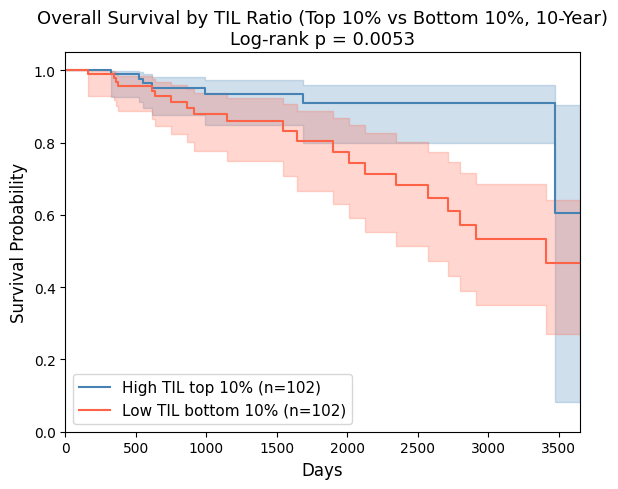

In [27]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# ── Parameters ────────────────────────────────────────────────
YEARS       = 10      # follow-up window (years); set None for no truncation
PERCENTILE  = 0.1     # e.g. 0.10 = top 10% vs bottom 10%
# ──────────────────────────────────────────────────────────────

MAX_DAYS = int(YEARS * 365) if YEARS is not None else None

# Build survival data: use days_to_death for deceased, else days_to_last_followup
df_surv = df_merged.copy()
df_surv["days_to_death"] = pd.to_numeric(df_surv["days_to_death"], errors="coerce")
df_surv["days_to_last_followup"] = pd.to_numeric(df_surv["days_to_last_followup"], errors="coerce")

df_surv["OS_days"] = df_surv["days_to_death"].where(
    df_surv["vital_status"].str.upper() == "DEAD",
    other=df_surv["days_to_last_followup"],
)
df_surv["OS_event"] = (df_surv["vital_status"].str.upper() == "DEAD").astype(int)

# Drop rows with missing survival time
df_surv = df_surv.dropna(subset=["OS_days", "til_ratio"])
df_surv = df_surv[df_surv["OS_days"] > 0]

# Truncate follow-up if a window is specified
if MAX_DAYS is not None:
    df_surv["OS_event"] = df_surv["OS_event"].where(df_surv["OS_days"] <= MAX_DAYS, other=0)
    df_surv["OS_days"] = df_surv["OS_days"].clip(upper=MAX_DAYS)

# Select top and bottom groups by PERCENTILE
p_low  = df_surv["til_ratio"].quantile(PERCENTILE)
p_high = df_surv["til_ratio"].quantile(1 - PERCENTILE)
low  = df_surv[df_surv["til_ratio"] <= p_low]
high = df_surv[df_surv["til_ratio"] >= p_high]

pct_label = f"{int(PERCENTILE * 100)}%"
print(f"Bottom {pct_label} cutoff (≤{p_low:.4f}): n={len(low)}")
print(f"Top {pct_label}    cutoff (≥{p_high:.4f}): n={len(high)}")

# Log-rank test
results = logrank_test(
    high["OS_days"], low["OS_days"],
    event_observed_A=high["OS_event"], event_observed_B=low["OS_event"],
)
print(f"Log-rank p-value: {results.p_value:.4f}")

# Kaplan-Meier plot
fig, ax = plt.subplots(figsize=(6, 5))

kmf_high = KaplanMeierFitter()
kmf_high.fit(high["OS_days"], event_observed=high["OS_event"], label=f"High TIL top {pct_label} (n={len(high)})")
kmf_high.plot_survival_function(ax=ax, ci_show=True, color="steelblue")

kmf_low = KaplanMeierFitter()
kmf_low.fit(low["OS_days"], event_observed=low["OS_event"], label=f"Low TIL bottom {pct_label} (n={len(low)})")
kmf_low.plot_survival_function(ax=ax, ci_show=True, color="tomato")

year_label = f"{YEARS}-Year" if YEARS is not None else "All Follow-up"
ax.set_title(f"Overall Survival by TIL Ratio (Top {pct_label} vs Bottom {pct_label}, {year_label})\nLog-rank p = {results.p_value:.4f}", fontsize=13)
ax.set_xlabel("Days", fontsize=12)
ax.set_ylabel("Survival Probability", fontsize=12)
if MAX_DAYS is not None:
    ax.set_xlim(0, MAX_DAYS)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("km_til_top10_bottom10.png", dpi=600, bbox_inches="tight")
plt.savefig("km_til_top10_bottom10.svg", dpi=600, bbox_inches="tight")
print("Saved km_til_top10_bottom10.png and .svg")
plt.show()


## Executive Summary

This notebook quantifies Tumor-Infiltrating Lymphocyte (TIL) ratios from deep learning cell-detection outputs across **~1,100 TCGA-BRCA whole-slide images** and evaluates their prognostic significance.

**Key Findings:**
- TIL ratios were successfully computed for all slides with available model-output data and merged with TCGA clinical records.
- Patients were stratified into **top 10%** (highest immune infiltration) and **bottom 10%** (lowest immune infiltration) TIL groups.
- Kaplan-Meier curves were plotted over a **10-year follow-up** window with a log-rank test to quantify survival differences.

**Interpretation:**
A low log-rank p-value (< 0.05) supports the hypothesis that higher TIL infiltration confers a survival benefit in BRCA — consistent with published evidence that immune-hot breast tumors respond better to systemic treatment.

**Output files:** `km_til_top10_bottom10.png` and `km_til_top10_bottom10.svg` (600 DPI) saved to the working directory.

**Limitations:**
- TIL ratio is derived from model predictions and may differ from pathologist-assessed TIL scores.
- Patients missing from either the clinical file or the model-output set are excluded.
- Confounders (e.g., tumor subtype, treatment) are not adjusted for in this unadjusted KM analysis.